In [4]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld_env import get_task1_gridworld, get_task2_gridworld, get_task3_gridworld
from utils import paint_gridworld

## A Look Around GridWorld

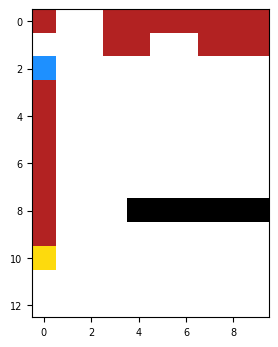

In [5]:
# Initiating the Environment. The method get_task1_gridworld
# initialises the environment for the task 1. Similarly there are methods to initialise the environment 
# for the other tasks
env1 = get_task1_gridworld()

# This is how the environment looks like
paint_gridworld(env1, figsize=(4,4), ticksize=7)

## Example of running a simulation 

In [6]:
reward_lst = []

# Initialise the environment
# An arbitary gamma value is used here. You may need to change this!
env1 = get_task1_gridworld()

# Reset the environment to start from the starting location. 
# The reset() method returns the state, reward, and whether the episode is done or not
# More information can be found under the definition of the method
_, state, reward, done = env1.reset()
reward_lst.append(reward)

# While the trial is not done, i.e. the agent has not fallen into lava,
# the maximum length of the episode has not been exceeded, and the target has not been reached
while not done:
    
    # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
    # corresponding to ['N', 'S', 'E', 'W']
    # More information can be found under the definition of the method
    # In this very simple example for each step we choose a random action
    _, state, reward, done = env1.step(np.random.choice(4))
    reward_lst.append(reward)

print(f'Collected rewards of an episode: {reward_lst}')

Collected rewards of an episode: [0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -10.0]


In [25]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

class Q_agent():
# The solve method should take the n_episodes and env as a parameter, 
# but otherwise you can modify the definition of this method
  def solve(self, env, n_episodes=500, gamma=0.1, alpha=0.1, epsilon=0.1, first_hidden_size=10, second_hidden_size=10):
    """
    Solve a given GridWorld environment using Q-learning
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """
    current_loc = env._starting_loc
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self.first_hidden_size = first_hidden_size
    self.second_hidden_size = second_hidden_size
    shape = env.get_gridshape()
    self.Q = np.zeros((self.states, self.actions))
    #self.W1 = np.random.randn(self.states, self.first_hidden_size) * 0.01
    #self.b1 = np.zeros(self.first_hidden_size)
    #self.W2 = np.random.randn(self.first_hidden_size, self.second_hidden_size) * 0.01
    #self.b2 = np.zeros(self.second_hidden_size)
    #self.W3 = np.random.rand(self.second_hidden_size, self.actions) * 0.01
    #self.b3 = np.zeros(self.actions)
    self._alpha = alpha#Learning Rate
    self._epsilon = epsilon#Explore Rate
    self._gamma = gamma#Discount
    total_steps = []
    policy_lst = []
    total_rewards = []

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)
      # While the trial is not done, i.e. the agent has not fallen into lava,
      # the maximum length of the episode has not been exceeded, and the target has not been reached
      while not done:
        # Take a step using the step() function and passing in one of the available actions [0, 1, 2, 3] 
        # corresponding to ['N', 'S', 'E', 'W']
        # More information can be found under the definition of the method
        # In this very simple example for each step we choose a random action
        action = self.epsilon_greedy_policy(state)
        _, next_state, reward, done = env.step(action)
        self.update_Q(state, action, next_state, reward)
        state = next_state
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    policy = policy_lst[index_of_best]

    # You may use these outputs to plot graphs
    #print(f"Q VALUES: {self.Q}")
    return policy, total_rewards, total_steps

  def update_Q(self, state, action, next_state, reward):
    self.Q[state, action] += self._alpha * (reward + self._gamma*np.max(self.Q[next_state]) - self.Q[state, action])

  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4)
    else:
      action = np.random.choice(optimal_actions)
      return action

In [29]:
class SARSA_agent():
  # The solve method should take the n_episodes and env as a parameter, 
  # but otherwise you can modify the definition of this method
  def solve(self, env, n_episodes=500, 
             # Extra parameters:
            gamma=0.1, alpha=0.1, epsilon=0.1, ):
    """
    Solve a given GridWorld environment using SARSA
    input: env {GridWorld object} -- GridWorld to solve
    output:
      - policy {np.array} -- Optimal policy found to solve the given GridWorld environment
      - total_rewards {list of float} -- Corresponding list of successive total non-discounted sum of reward for each trial
      - total_steps {list of float} -- Corresponding list of successive total non-discounted sum of steps for each trial
    """

    # Initialise your variables
    self.states = env.get_state_size()
    self.actions = env.get_action_size()
    self._alpha = alpha#Learning rate
    self._gamma = gamma#Discount
    self._epsilon = epsilon#Explore rate
    self.Q = np.zeros((self.states, self.actions))
    total_steps = []
    policy_lst = []
    total_rewards = []

    ####
    # Add your code here
    # WARNING: this agent only has access to env.reset() and env.step()
    # You should not use env.get_absorbing() to compute any value
    ####

    for e in range(n_episodes):
      _, state, reward, done = env.reset()
      current_total_steps = 0
      current_policy = [state]
      rewards = []
      rewards.append(reward)

      action = self.epsilon_greedy_policy(state)

      while not done:
        _, next_state, reward, done = env.step(action)
        next_action = self.epsilon_greedy_policy(next_state)
        self.update_Q(state, action, next_state, next_action, reward)
        state = next_state
        action = next_action
        rewards.append(reward)
        current_policy.append(state)
        current_total_steps += 1
      
      total_rewards.append(np.average(rewards))
      total_steps.append(current_total_steps)
      policy_lst.append(current_policy)

    index_of_best = np.argmax(total_rewards)
    policy = policy_lst[index_of_best]
    
    # You may use these outputs to plot graphs
    return policy, total_rewards, total_steps

  def update_Q(self, state, action, next_state, next_action, reward):
    #Q(s, a) ← Q(s, a) + η * [r + γ * Q(s', a') - Q(s, a)] == SARSA
    self.Q[state, action] += self._alpha * (reward + self._gamma*self.Q[next_state, next_action] - self.Q[state, action])

  def epsilon_greedy_policy(self, state):
    #Determine optimal action(s)
    max_value = np.max(self.Q[state])
    optimal_actions = []
    for action in range(self.actions):
      if self.Q[state, action] == max_value:
        optimal_actions.append(action)
    #Determine whether the agent follows the optimal action or chooses to explore
    if np.random.rand() < self._epsilon:
      return np.random.choice(4)
    else:
      action = np.random.choice(optimal_actions)
      return action

# Task 1 - Single Target, Deterministic Rewards:

In [9]:
# Example of Hyperparameters
# This is just an example, you can add to this depending on which method you utilise

s_gamma_1 = 0.57 #Discount
s_alpha_1 = 0.24 #Learning Rate
s_epsilon_1 = 0.01 #Explore Rate
s_n_episodes_1 = 1000

q_gamma_1 = 0.99
q_alpha_1 = 0.1
q_epsilon_1 = 0.05
q_n_episodes_1 = 1000
q_first_hidden_size_1 = 10
q_second_hidden_size_1 = 10

In [10]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env1 = get_task1_gridworld()

In [36]:
# Example of running SARSA
agent = SARSA_agent()
policy, sarsa_rewards_1, total_steps = agent.solve(env1, gamma=s_gamma_1, alpha=s_alpha_1, epsilon=s_epsilon_1, n_episodes=s_n_episodes_1)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {sarsa_rewards_1}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
TOTAL REWARD: [-5.0, -0.06944444444444445, -0.8333333333333334, -1.4285714285714286, -0.0364963503649635, -0.17857142857142858, 0.0, -0.05319148936170213, 0.0, -0.10869565217391304, 0.0, 0.0, -0.04048582995951417, -0.23809523809523808, 0.0, -0.024390243902439025, -0.08403361344537816, -0.02610966057441253, -0.3125, -0.14285714285714285, -0.041666666666666664, 0.0, 2.5, -0.025, 0.0, 10.869565217391305, -0.13157894736842105, 0.0, 1.25, 1.858736059479554, 3.9682539682539684, 6.4935064935064934, 0.0, 5.376344086021505, 2.1739130434782608, 14.705882352941176, 12.5, 2.092050209205021, 6.25, 8.620689655172415, 26.31578947368421, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45454545454545, 45.45

In [38]:
# Example of running Q-Learning
agent = Q_agent()
policy, q_learning_rewards_1, total_steps = agent.solve(env1, gamma=q_gamma_1, alpha=q_alpha_1, epsilon=q_epsilon_1, n_episodes=q_n_episodes_1, first_hidden_size=q_first_hidden_size_1)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {q_learning_rewards_1}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (5, 1), (4, 1), (3, 1), (2, 1), (2, 0)]
TOTAL REWARD: [-5.0, -0.37037037037037035, -0.10101010101010101, -0.25, -2.5, -0.02544529262086514, -0.20408163265306123, -0.035842293906810034, -0.4, -0.02570694087403599, -0.03816793893129771, -0.09009009009009009, 0.0, 0.0, -0.031446540880503145, -0.03937007874015748, -0.1, -0.09345794392523364, 0.0, 3.6231884057971016, -0.028735632183908046, 0.0, -0.18518518518518517, -0.03745318352059925, -0.022779043280182234, -0.02865329512893983, -0.14925373134328357, 1.0460251046025104, 1.6339869281045751, 1.1904761904761905, 0.0, -3.3333333333333335, -0.20833333333333334, 1.1210762331838564, 2.242152466367713, 1.3966480446927374, 1.0351966873706004, 0.0, 3.4482758620689653, 38.46153846153846, 10.416666666666666, 26.31578947368421, 26.31578947368421, 6.410256410256411, 19.23076923076923, 33.333333333333336, 38.46153846153846, 29.41176470588235, 38.46153846153846, 38.46153846153846, 38.46153846153

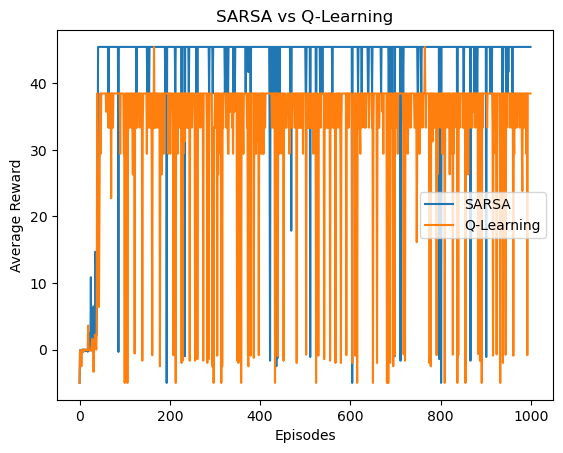

In [39]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_1)
q_average = np.average(q_learning_rewards_1)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_1).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_1).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 2 - Dual Targets with Stochastic Rewards

In [157]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env2 = get_task2_gridworld()

In [671]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_2 = 0.75 #Discount
s_alpha_2 = 0.3 #Learning Rate
s_epsilon_2 = 0.01 #Explore Rate
s_n_episodes_2 = 2500

policy, sarsa_rewards_2, total_steps = agent.solve(env2, gamma=s_gamma_2, alpha=s_alpha_2, epsilon=s_epsilon_2, n_episodes=s_n_episodes_2)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (10, 2), (9, 2), (9, 3), (8, 3), (7, 3), (7, 4), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 60.89861205946269, 68.391

In [672]:
# Example of running Q-Learning
q_gamma_2 = 0.75 #Discount
q_alpha_2 = 0.3 #Learning Rate
q_epsilon_2 = 0.05 #Explore Rate
q_n_episodes_2 = 2500

agent = Q_agent()
policy, q_learning_rewards_2, total_steps = agent.solve(env2, gamma=q_gamma_2, alpha=q_alpha_2, epsilon=q_epsilon_2, n_episodes=q_n_episodes_2)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (9, 1), (8, 1), (7, 1), (6, 1), (6, 2), (5, 2), (4, 2), (3, 2), (3, 1), (2, 1), (2, 0)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 60.89861205946269, 68.391630717477

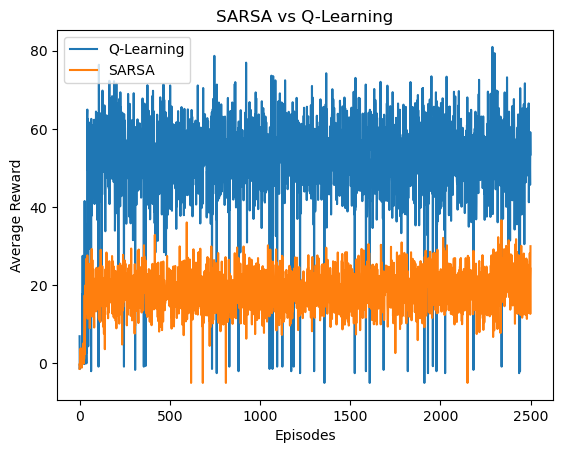

In [673]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_2)
q_average = np.average(q_learning_rewards_2)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_2).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_2).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()

# Task 3 - Stochastic Transitions and Rewards

In [568]:
# This should be the definition of the gridworld for task 1. DO NOT CHANGE THIS
env3 = get_task3_gridworld()

In [674]:
# Example of running SARSA
agent = SARSA_agent()

s_gamma_3 = 0.85 #Discount
s_alpha_3 = 0.3 #Learning Rate
s_epsilon_3 = 0.03 #Explore Rate
s_n_episodes_3 = 5000

policy, sarsa_rewards_3, total_steps = agent.solve(env3, gamma=s_gamma_3, alpha=s_alpha_3, epsilon=s_epsilon_3, n_episodes=s_n_episodes_3)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (10, 2), (10, 3), (9, 3), (8, 3), (8, 2), (7, 2), (7, 1), (7, 2), (6, 2), (5, 2), (4, 2), (3, 2), (2, 2), (2, 1), (2, 0)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 

In [675]:
# Example of running Q-Learning
q_gamma_3 = 0.75 #Discount
q_alpha_3 = 0.35 #Learning Rate
q_epsilon_3 = 0.08 #Explore Rate
q_n_episodes_3 = 5000

agent = Q_agent()
policy, q_learning_rewards_3, total_steps = agent.solve(env3, gamma=q_gamma_3, alpha=q_alpha_3, epsilon=q_epsilon_3, n_episodes=q_n_episodes_3)

loc_policy = []
for i in range(len(policy)):
    loc_policy.append(env1.get_loc_from_state(policy[i]))

print(f"POLICY: {loc_policy}")
print(f"TOTAL REWARD: {total_rewards}")
print(f"TOTAL STEPS: {total_steps}")

POLICY: [(10, 0), (10, 1), (10, 2), (9, 2), (9, 3), (8, 3), (7, 3), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9)]
TOTAL REWARD: [-5.0, -0.07092198581560284, -0.10752688172043011, -0.1, -0.30303030303030304, 3.287208540501406, -0.09615384615384616, -0.1111111111111111, -0.2564102564102564, 0.0, 0.0, 2.9808641626643335, -0.02865329512893983, -0.055248618784530384, 2.7300493622180975, 2.757793396373398, 0.5326563344761203, 0.7783689098825558, -1.1111111111111112, 0.0, 0.9457265240564114, 4.685463970520781, -0.06802721088435375, 2.9834932808361274, 9.012858403859733, 6.392531619679419, 17.44022345666054, 3.3120755455194018, 40.5427925839487, 1.6750583607267986, -5.0, 3.8761494619956536, 3.8458940192829854, 1.6201751839360887, 25.647967747035906, 40.42113523908907, 25.530964907189162, 50.400276198606555, 45.25926731900939, 46.97611556064894, 61.044622512460116, 72.10942168301663, 61.935940089507056, 58.32140096875614, 65.42448422626684, 48.56474803968968, 60.89861205946269, 68.391

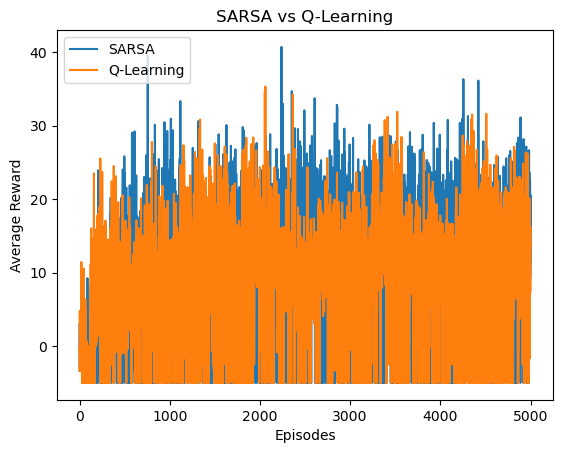

In [676]:
# Do your plots below! Include any new function definitions in this jupyter notebook!
sarsa_average = np.average(sarsa_rewards_3)
q_average = np.average(q_learning_rewards_3)
if sarsa_average > q_average:
    plt.plot(np.mean(np.array(sarsa_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
    plt.plot(np.mean(np.array(q_learning_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
else:
    plt.plot(np.mean(np.array(q_learning_rewards_3).reshape(-1, 1), axis=1), label='Q-Learning')
    plt.plot(np.mean(np.array(sarsa_rewards_3).reshape(-1, 1), axis=1), label='SARSA')
plt.xlabel('Episodes')
plt.ylabel('Average Reward')
plt.legend()
plt.title('SARSA vs Q-Learning')
plt.show()